In [2]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
torch.set_num_threads(16)

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}")

Using device cuda


In [4]:
mean=(0.5, 0.5, 0.5)
std=(0.5, 0.5, 0.5)

In [5]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

In [6]:
trainset=torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 78.1MB/s] 


In [7]:
train_loader=DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
test_loader=DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

In [8]:
print(len(testset), len(trainset))

10000 50000


In [9]:
#Simple Convolutional NN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.batch1=nn.BatchNorm2d(32)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(kernel_size=2)

        self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.batch2=nn.BatchNorm2d(64)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(kernel_size=2)

        self.conv3=nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.batch3=nn.BatchNorm2d(128)
        self.relu3=nn.ReLU()
        self.pool3=nn.MaxPool2d(kernel_size=2)

        self.flatten=nn.Flatten()
        self.fc1=nn.Linear(128*4*4, 512)
        self.dropout=nn.Dropout(0.5)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(512, 10)

    def forward(self, x):
        x=self.pool1(self.relu1(self.batch1(self.conv1(x))))
        x=self.pool2(self.relu2(self.batch2(self.conv2(x))))
        x=self.pool3(self.relu3(self.batch3(self.conv3(x))))
        x=self.flatten(x)
        x=self.fc1(x)
        x=self.relu(x)
        x=self.dropout(x)
        x=self.fc2(x)
        return x

In [10]:
model=SimpleCNN().to(device)
#loading previously trained parameters to ensure consistency
#model.load_state_dict(torch.load('model_weights.pth'))
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()


In [11]:
def train_model(model, trainloader, epochs):
    loss_function=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001)
    losses=[]

    for epoch in range(epochs):
        total_loss=0
        for images, labels in trainloader:
            images=images.to(device)
            labels=labels.to(device)
            optimizer.zero_grad()
            outputs=model(images)
            loss=loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()

        epoch_loss=total_loss/len(trainloader)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}  Loss: {total_loss/len(trainloader) :.3f}")

    return losses

In [12]:
cnn=SimpleCNN().to(device)
#cnn.load_state_dict(torch.load('cnn_weights.pth'))
cnn_losses=train_model(cnn, train_loader, epochs=20)

Epoch 1/20  Loss: 1.344
Epoch 2/20  Loss: 0.972
Epoch 3/20  Loss: 0.840
Epoch 4/20  Loss: 0.753
Epoch 5/20  Loss: 0.684
Epoch 6/20  Loss: 0.624
Epoch 7/20  Loss: 0.575
Epoch 8/20  Loss: 0.519
Epoch 9/20  Loss: 0.484
Epoch 10/20  Loss: 0.443
Epoch 11/20  Loss: 0.408
Epoch 12/20  Loss: 0.369
Epoch 13/20  Loss: 0.345
Epoch 14/20  Loss: 0.312
Epoch 15/20  Loss: 0.290
Epoch 16/20  Loss: 0.263
Epoch 17/20  Loss: 0.246
Epoch 18/20  Loss: 0.221
Epoch 19/20  Loss: 0.206
Epoch 20/20  Loss: 0.202


In [13]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,147,914


In [14]:
def evaluate(model, testloader):
    correct=0
    total=0

    with torch.no_grad():
        for images, labels in testloader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            _, predicted=torch.max(outputs, 1)
            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    print(f"Accuracy: {100*correct/total:.2f}%")

In [15]:
evaluate(cnn, test_loader)

Accuracy: 77.69%


In [16]:
#Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.relu=nn.ReLU()
        self.conv_block=nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(out_channels)
        )

        self.shortcut=nn.Sequential()
        if stride!=1 or in_channels ==out_channels:
            self.shortcut=nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out=self.conv_block(x)
        out=out+self.shortcut(x)
        out=self.relu(out)
        return out

In [17]:
# Residual Network
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.prep=nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU()
        )
        self.layer1=ResidualBlock(64, 64)
        self.layer2=ResidualBlock(64, 128, stride=2)
        self.layer3=ResidualBlock(128,256, stride=2)
        self.layer4=ResidualBlock(256, 512, stride=2)
        self.classifier=nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(512, num_classes))

    def forward(self, x):
        x=self.prep(x)
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=self.layer4(x)
        x=self.classifier(x)
        return x


In [18]:
resnet=ResNet().to(device)
#loading parameters
#resnet.load_state_dict(torch.load('resnet_weights.pth'))
print(resnet)
total_params=sum(p.numel() for p in resnet.parameters())
print(f"Total parameters: {total_params:,}")

ResNet(
  (prep): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): ResidualBlock(
    (relu): ReLU()
    (conv_block): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (shortcut): Sequential(
      (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (relu): ReLU()
    (conv_block): Sequential(
      (0): Conv2d(64, 128, kernel_siz

In [19]:
#train resnet
resnet_losses=train_model(resnet, train_loader, epochs=20)

Epoch 1/20  Loss: 1.216
Epoch 2/20  Loss: 0.759
Epoch 3/20  Loss: 0.556
Epoch 4/20  Loss: 0.416
Epoch 5/20  Loss: 0.306
Epoch 6/20  Loss: 0.206
Epoch 7/20  Loss: 0.135
Epoch 8/20  Loss: 0.093
Epoch 9/20  Loss: 0.069
Epoch 10/20  Loss: 0.058
Epoch 11/20  Loss: 0.050
Epoch 12/20  Loss: 0.051
Epoch 13/20  Loss: 0.043
Epoch 14/20  Loss: 0.038
Epoch 15/20  Loss: 0.041
Epoch 16/20  Loss: 0.032
Epoch 17/20  Loss: 0.032
Epoch 18/20  Loss: 0.037
Epoch 19/20  Loss: 0.028
Epoch 20/20  Loss: 0.021


In [20]:
evaluate(resnet, test_loader)

Accuracy: 82.11%


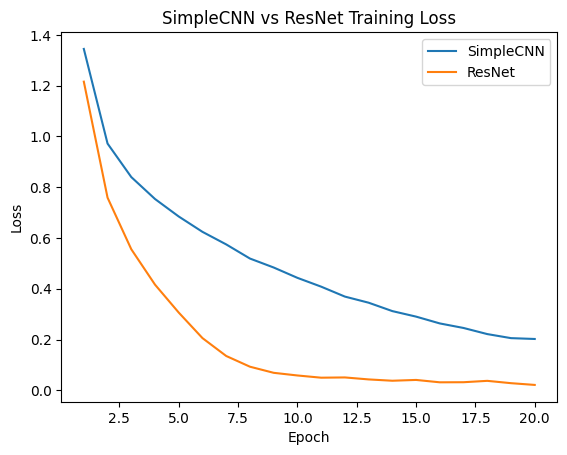

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

plt.plot(epochs, cnn_losses, label='SimpleCNN')
plt.plot(epochs, resnet_losses, label='ResNet')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SimpleCNN vs ResNet Training Loss')
plt.legend()
plt.show()

In [22]:
print("SimpleCNN:\n")
evaluate(cnn, test_loader)
print("\nResNet:\n")
evaluate(resnet, test_loader)

SimpleCNN:

Accuracy: 77.69%

ResNet:

Accuracy: 82.11%


In [47]:
#saving the parameters
torch.save(cnn.state_dict(), 'cnn_weights.pth')
torch.save(resnet.state_dict(), 'resnet_weights.pth')

In [24]:
#displaying some predictions vs labels
images, labels= next(iter(test_loader))
with torch.no_grad():
  cnn_outputs=cnn(images.to(device))
  resnet_outputs=resnet(images.to(device))

_, cnn_preds=torch.max(cnn_outputs, dim=1)
_, resnet_preds= torch.max(resnet_outputs, dim=1)
classes=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

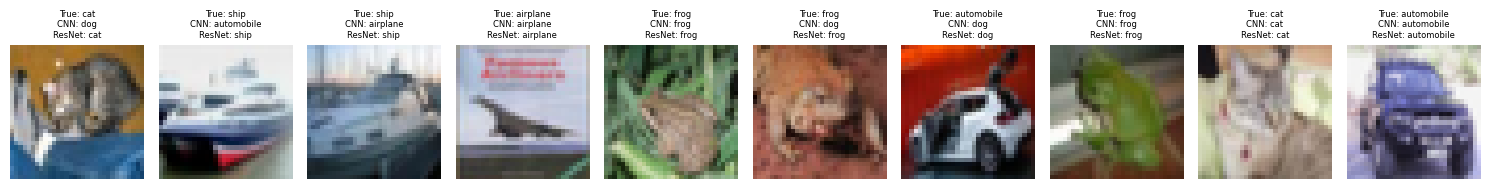

In [25]:
def show_image(img):
  img=img/2 +0.5
  img=img.numpy()
  plt.imshow(np.transpose(img,(1,2,0)))

plt.figure(figsize=(15,5))
for i in range(10):
  plt.subplot(1, 10, i+1)
  show_image(images[i])
  true_label=classes[labels[i]]
  cnn_label=classes[cnn_preds[i]]
  resnet_label=classes[resnet_preds[i]]
  plt.title(f"True: {true_label}\nCNN: {cnn_label}\nResNet: {resnet_label}", fontsize=6)
  plt.axis("off")
plt.tight_layout()
plt.show()

ResNet outperforms SimpleCNN


Trying to achieve better accuracy

In [26]:
#adding augmentation for better data
train_transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
test_transform=transform

In [27]:
trainset2=torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset2=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

In [28]:
train_loader2=DataLoader(trainset2, batch_size=128, shuffle=True, num_workers=2)
test_loader2=DataLoader(testset2, batch_size=128, shuffle=False, num_workers=2)

In [29]:
#redefining train_model with a scheduler
def train_model_sched(model, trainloader, epochs, scheduler=None):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_loss = total_loss / len(trainloader)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.3f}")

        if scheduler is not None:
            scheduler.step()

    return losses

In [33]:
#new SimpleCNN
print("New SimpleCNN:\n")
new_cnn=SimpleCNN().to(device)
#new_cnn.load_state_dict(torch.load('new_resnet_weights.pth'))
optimizer_cnn=torch.optim.Adam(new_cnn.parameters(), lr=0.01)
scheduler_cnn=torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=4, gamma=0.5)
new_loss_cnn=train_model_sched(new_cnn, train_loader2, epochs=20, scheduler=scheduler_cnn)
evaluate(new_cnn, test_loader2)


#new ResNet
print("\nNew ResNet:\n")
new_resnet=ResNet().to(device)
#new_resnet.load_state_dict(torch.load('new_resnet_weights.pth'))
optimizer_resnet=torch.optim.Adam(new_resnet.parameters(), lr=0.001)
scheduler_resnet=torch.optim.lr_scheduler.StepLR(optimizer_resnet, step_size=5, gamma=0.5)
new_loss_resnet=train_model_sched(new_resnet, train_loader2, epochs=20, scheduler=scheduler_cnn)
evaluate(new_resnet, test_loader2)

New SimpleCNN:

Epoch 1/20  Loss: 1.610


/tmp/ipykernel_55/255147828.py:24: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 2/20  Loss: 1.336
Epoch 3/20  Loss: 1.205
Epoch 4/20  Loss: 1.131
Epoch 5/20  Loss: 1.069
Epoch 6/20  Loss: 1.019
Epoch 7/20  Loss: 0.979
Epoch 8/20  Loss: 0.941
Epoch 9/20  Loss: 0.906
Epoch 10/20  Loss: 0.880
Epoch 11/20  Loss: 0.856
Epoch 12/20  Loss: 0.832
Epoch 13/20  Loss: 0.817
Epoch 14/20  Loss: 0.806
Epoch 15/20  Loss: 0.783
Epoch 16/20  Loss: 0.769
Epoch 17/20  Loss: 0.759
Epoch 18/20  Loss: 0.745
Epoch 19/20  Loss: 0.731
Epoch 20/20  Loss: 0.717
Accuracy: 76.14%

New ResNet:

Epoch 1/20  Loss: 1.394
Epoch 2/20  Loss: 0.994
Epoch 3/20  Loss: 0.826
Epoch 4/20  Loss: 0.712
Epoch 5/20  Loss: 0.635
Epoch 6/20  Loss: 0.573
Epoch 7/20  Loss: 0.532
Epoch 8/20  Loss: 0.492
Epoch 9/20  Loss: 0.459
Epoch 10/20  Loss: 0.434
Epoch 11/20  Loss: 0.410
Epoch 12/20  Loss: 0.385
Epoch 13/20  Loss: 0.362
Epoch 14/20  Loss: 0.347
Epoch 15/20  Loss: 0.328
Epoch 16/20  Loss: 0.313
Epoch 17/20  Loss: 0.298
Epoch 18/20  Loss: 0.283
Epoch 19/20  Loss: 0.275
Epoch 20/20  Loss: 0.262
Accuracy: 8

In [46]:
torch.save(new_cnn.state_dict(), 'new_cnn_weights.pth')
torch.save(new_resnet.state_dict(), 'new_resnet_weights.pth')

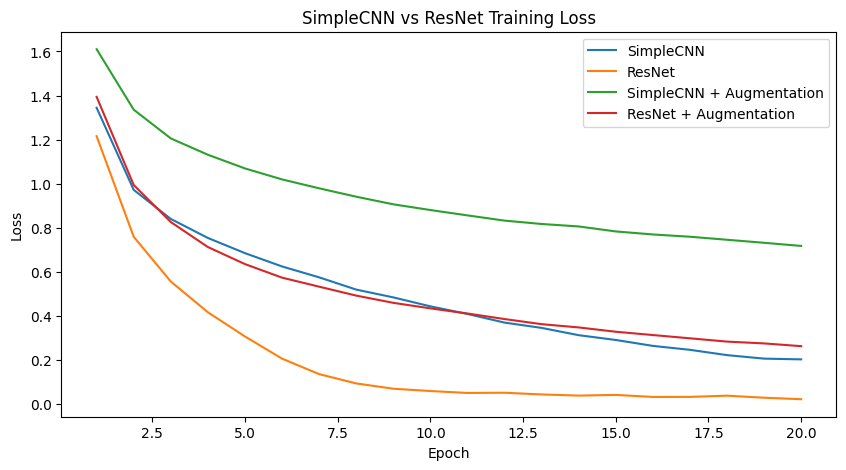

In [35]:
epochs_20 = range(1, 21)

plt.figure(figsize=(10, 5))
plt.plot(epochs_20, cnn_losses, label='SimpleCNN')
plt.plot(epochs_20, resnet_losses, label='ResNet')
plt.plot(epochs_20, new_loss_cnn, label='SimpleCNN + Augmentation')
plt.plot(epochs_20, new_loss_resnet, label='ResNet + Augmentation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SimpleCNN vs ResNet Training Loss')
plt.legend()
plt.show()

In [36]:
print("SimpleCNN:\n")
evaluate(cnn, test_loader)
print("\nResNet:\n")
evaluate(resnet, test_loader)
print("\nAugmented SimpleCNN:\n")
evaluate(new_cnn, test_loader2)
print("\nAugmented ResNet:\n")
evaluate(new_resnet, test_loader2)

SimpleCNN:

Accuracy: 77.39%

ResNet:

Accuracy: 82.11%

Augmented SimpleCNN:

Accuracy: 75.54%

Augmented ResNet:

Accuracy: 85.76%


Oddly, the un-augmented network converges faster than the Augmented ones, yet the Augmented ResNet outperforms the un-augmented ResNet

In [37]:
#displaying some predictions vs labels
images, labels= next(iter(test_loader2))
with torch.no_grad():
  new_cnn_outputs=new_cnn(images.to(device))
  new_resnet_outputs=new_resnet(images.to(device))

_, new_cnn_preds=torch.max(new_cnn_outputs, dim=1)
_, new_resnet_preds= torch.max(new_resnet_outputs, dim=1)
classes=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

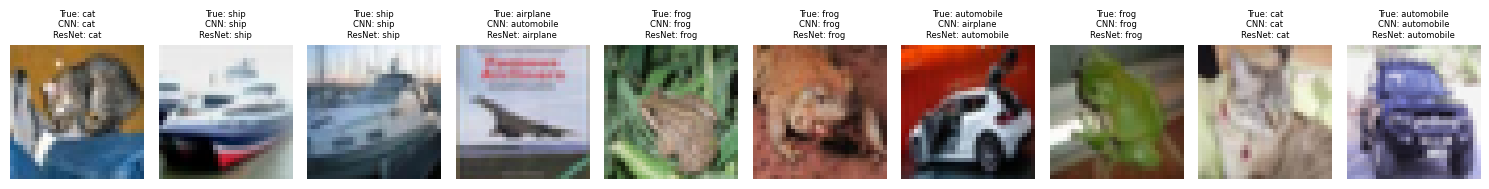

In [38]:
def show_image(img):
  img=img/2 +0.5
  img=img.numpy()
  plt.imshow(np.transpose(img,(1,2,0)))

plt.figure(figsize=(15,5))
for i in range(10):
  plt.subplot(1, 10, i+1)
  show_image(images[i])
  true_label=classes[labels[i]]
  cnn_label=classes[new_cnn_preds[i]]
  resnet_label=classes[new_resnet_preds[i]]
  plt.title(f"True: {true_label}\nCNN: {cnn_label}\nResNet: {resnet_label}", fontsize=6)
  plt.axis("off")
plt.tight_layout()
plt.show()

In [39]:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = new_resnet(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())   
        all_labels.extend(labels.cpu().numpy())   

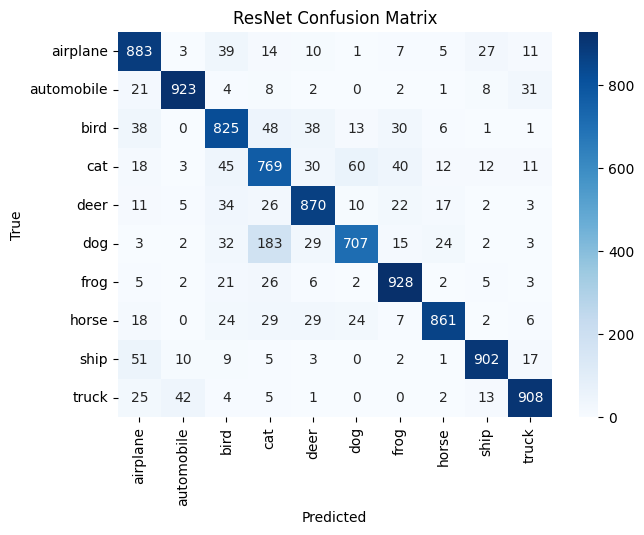

airplane    : 88.3%
automobile  : 92.3%
bird        : 82.5%
cat         : 76.9%
deer        : 87.0%
dog         : 70.7%
frog        : 92.8%
horse       : 86.1%
ship        : 90.2%
truck       : 90.8%


In [44]:
#heatmap of predictions
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=classes, 
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet Confusion Matrix')
plt.show()

for i, classname in enumerate(classes):
    correct=cm[i][i]
    total=cm[i].sum()
    print(f"{classname:12s}: {100*correct/total :.1f}%")

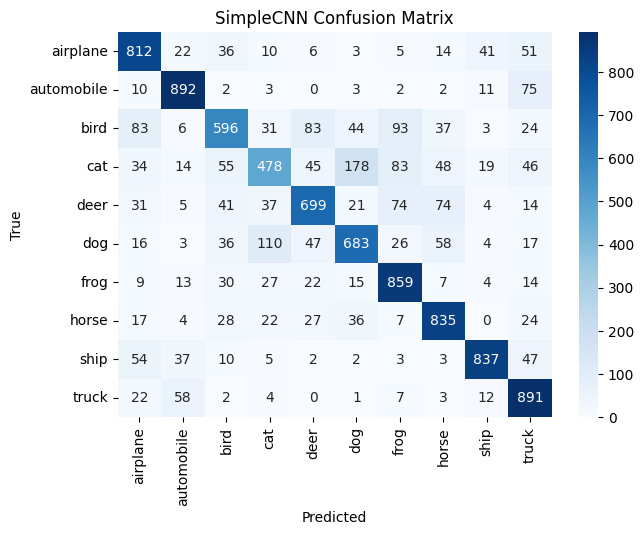

airplane    : 81.2%
automobile  : 89.2%
bird        : 59.6%
cat         : 47.8%
deer        : 69.9%
dog         : 68.3%
frog        : 85.9%
horse       : 83.5%
ship        : 83.7%
truck       : 89.1%


In [45]:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = new_cnn(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())   
        all_labels.extend(labels.cpu().numpy()) 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=classes, 
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SimpleCNN Confusion Matrix')
plt.show()
for i, classname in enumerate(classes):
    correct=cm[i][i]
    total=cm[i].sum()
    print(f"{classname:12s}: {100*correct/total :.1f}%")